# FABN SAP Optimizer — Phase 2: Daily Dynamic Re-Optimization Backtest

Tests the thesis of `SAP.pdf`: does **daily** dynamic re-optimization beat a static buy-and-hold
portfolio under statutory (book-yield) economics? Starting from cash on day 1 we build an optimal
book, then **every trading day** we re-optimize and take any opportunity that — net of **trading
cost, capital-cost change, borrowing cost, and lending revenue** — improves value. Realized net
statutory income is accrued daily and accumulated.

---

## 1. The trade decision (what changed vs the quarterly version)

Each day we hold $h^{prev}$ and choose **buys** $b_i\ge0$ and **sells** $0\le s_i\le h^{prev}_i$, so
$$h_i = h^{prev}_i + b_i - s_i .$$

**Retained vs new lots (amortized cost).** Under SAP a bond's book yield is locked at purchase. So:
- retained notional $(h^{prev}_i-s_i)$ keeps its **locked** in-force yield $y^{bk}_i$;
- newly bought notional $b_i$ enters at today's **market** yield $y^{mkt}_i$.

The decision therefore compares *what a new bond yields* against *the locked yield you give up* — the
true pickup — not market-vs-market. This is linear in $(b_i,s_i)$.

**Decision objective** (horizon $T$ = years remaining to FABN maturity; a holding is valued over the
life it would actually earn over, so a one-time trade cost is weighed against horizon income):
$$
\max_{b,s\ge0}\;
T\!\sum_i\!\big[(h^{prev}_i-s_i)(y^{bk}_i-r^F)+b_i(y^{mkt}_i-r^F)\big]
-T\lambda\!\sum_i\theta_i h_i
-\sum_i\tau_i(b_i+s_i)
+\,r_{save}\,\delta\!\sum_q B_q
-\,r_{borrow}\,\delta\!\sum_q s^{net}_q
$$

So all four of your terms enter the swap decision: **trading cost** $\tau_i(b_i+s_i)$,
**capital-cost change** $T\lambda\theta_i h_i$, **lending revenue** $r_{save}\delta\sum B_q$,
**borrowing cost** $r_{borrow}\delta\sum s^{net}_q$.

Constraints (linear): budget $\sum h_i=H$; sell cap $s_i\le h^{prev}_i$; duration band
$\lvert\sum D_i h_i - D^L H\rvert\le\varepsilon_D H$; issuer cap $\sum_{i\in g}h_i\le\delta_{iss}H$;
lending-facility balance recursion to maturity; PV-shortfall cap $\sum_q DF_q s^{net}_q\le\phi\,PV(L)$.

---

## 2. Realized daily P&L (accrual — kept separate, no double counting)

Over the day $[t_k,t_{k+1}]$ of length $\Delta_k$ (years), after the trade and the book-yield ledger
update:
$$
\text{Net}_k=\Delta_k\!\sum_i h_{k,i}\big(y^{bk}_{k,i}-r^F\big)
-\Delta_k\,\lambda\!\sum_i\theta_i h_{k,i}
-\sum_i\tau_{k,i}(b_{k,i}+s_{k,i})
$$
The book-yield ledger blends retained and bought lots:
$y^{bk}_{k,i}=\big[(h^{prev}_i-s_i)y^{bk}_{k-1,i}+b_i\,y^{mkt}_{k,i}\big]/h_{k,i}$.

Income accrues at the **locked** yield; the facility interest is a *decision-shaping* / ALM term
(full-horizon), so it is **not** re-accrued daily. **Matured** bonds redeem at par (no spread); their
cash is redeployed (dynamic) or held as cash earning $r^F$, i.e. net-zero spread (static).

**Honest limitations (unchanged):** IMR/AVR excluded — sale gains/losses not recognized, so this is a
*conservative* test (only forward book-yield pickup net of costs, not trading gains). Prices treated
as clean. The dynamic-vs-static outcome is data-driven, not assumed.

---
## Section 0 — Imports & Bulk Data Load (BigQuery + FRED, once)

In [1]:
import numpy as np, pandas as pd, time, warnings
import gurobipy as gp
from gurobipy import GRB
from google.cloud import bigquery
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import fabn_finance as ff          # shared, unit-tested math (IRR, duration, C-1, IMRLedger)
warnings.filterwarnings("ignore")

PROJECT_ID    = "insurance-backed-securities"
FABN_ISSUE    = pd.Timestamp("2022-09-06")
FABN_MATURITY = pd.Timestamp("2027-09-06")
FABN_COUPON   = 0.03205
r_FABN        = FABN_COUPON
H             = 500_000_000.0
client = bigquery.Client(project=PROJECT_ID)
print("Connected:", client.project)

Connected: insurance-backed-securities


In [2]:
# Static attributes
fixed = client.query(f"""
    SELECT CUSIP, `Amt Out` AS amt_out, Cpn AS coupon, Maturity AS maturity,
           `BBG Composite` AS rating_sp, `Mac Dur _Ask_` AS mac_dur_bbg,
           RTG_MOODY AS rating_moodys, BICS_LEVEL_1_SECTOR_NAME AS sector
    FROM `{PROJECT_ID}.Securities.Agg_Fixed_Field` WHERE CUSIP IS NOT NULL
""").to_dataframe().drop_duplicates(subset="CUSIP").reset_index(drop=True)
fixed["maturity"] = pd.to_datetime(fixed["maturity"])
CUSIPS = fixed["CUSIP"].tolist(); N = len(CUSIPS); cidx = {c:i for i,c in enumerate(CUSIPS)}
maturity64 = fixed.set_index("CUSIP").loc[CUSIPS,"maturity"].values.astype("datetime64[ns]")
annual_cpn = fixed.set_index("CUSIP").loc[CUSIPS,"coupon"].values/100.0
print(f"Universe N = {N}")

Universe N = 303


In [3]:
# C-1 RBC factor (theta)
C1_SP={"AAA":0.00158,"AA+":0.00271,"AA":0.00419,"AA-":0.00523,"A+":0.00657,"A":0.00816,"A-":0.01016,
       "BBB+":0.01261,"BBB":0.01523,"BBB-":0.02168,"BB+":0.03151,"BB":0.04537,"BB-":0.06017,"B+":0.07386,
       "B":0.09535,"B-":0.12428,"CCC+":0.16942,"CCC":0.23798,"CCC-":0.32975,"D":0.30000}
C1_MO={"Aaa":0.00158,"Aa1":0.00271,"Aa2":0.00419,"Aa3":0.00523,"A1":0.00657,"A2":0.00816,"A3":0.01016,
       "Baa1":0.01261,"Baa2":0.01523,"Baa3":0.02168,"Ba1":0.03151,"Ba2":0.04537,"Ba3":0.06017,"B1":0.07386,
       "B2":0.09535,"B3":0.12428,"Caa1":0.16942,"Caa2":0.23798,"Caa3":0.32975,"Ca":0.30000,"C":0.30000}
def _c1(sp,mo):
    if pd.notna(sp) and str(sp).strip() in C1_SP: return C1_SP[str(sp).strip()]
    if pd.notna(mo) and str(mo).strip() in C1_MO: return C1_MO[str(mo).strip()]
    return C1_SP["BBB"]
theta = np.array([_c1(fixed.loc[fixed.CUSIP==c,"rating_sp"].values[0],
                      fixed.loc[fixed.CUSIP==c,"rating_moodys"].values[0]) for c in CUSIPS])
ISSUER_GROUPS = {}
for i,c in enumerate(CUSIPS): ISSUER_GROUPS.setdefault(c[:6],[]).append(i)
print(f"theta range: {theta.min():.5f} – {theta.max():.5f}  | {len(ISSUER_GROUPS)} issuers")

theta range: 0.00158 – 0.02168  | 225 issuers


In [4]:
# Asset cash flows (per 100 face), pre-grouped per CUSIP for fast IRR
cf_all = client.query(f"""
    SELECT PaymentDate, CUSIP, Payment FROM `{PROJECT_ID}.Securities.Asset_Cashflows`
""").to_dataframe()
cf_all["PaymentDate"] = pd.to_datetime(cf_all["PaymentDate"])
cf_all = cf_all.groupby(["PaymentDate","CUSIP"], as_index=False)["Payment"].sum()
CF_BY = {}
for c,g in cf_all.groupby("CUSIP"):
    g = g.sort_values("PaymentDate")
    CF_BY[c] = (g["PaymentDate"].values.astype("datetime64[ns]"), g["Payment"].values/100.0)  # per $1 face
print(f"Cash-flow rows: {len(cf_all):,}")

Cash-flow rows: 2,740


In [5]:
# Daily price panels, wide (index=Date, cols=CUSIP), aligned to CUSIPS
def _wide(table, cast=False):
    expr = "SAFE_CAST(Price AS FLOAT64)" if cast else "Price"
    df = client.query(f"SELECT Date,CUSIP,{expr} AS Price FROM `{table}`").to_dataframe()
    df["Date"] = pd.to_datetime(df["Date"])
    return df.pivot_table(index="Date",columns="CUSIP",values="Price").sort_index().reindex(columns=CUSIPS)
mid_w = _wide(f"{PROJECT_ID}.Mid_Price.mid_long_raw")
bid_w = _wide(f"{PROJECT_ID}.Bid_Price.bid_long_raw")
ask_w = _wide(f"{PROJECT_ID}.Ask_Price.ask_long_raw", cast=True)
PANEL_DATES = mid_w.index
print(f"Price panel: {mid_w.shape[0]} days x {mid_w.shape[1]} bonds "
      f"({PANEL_DATES.min().date()} → {PANEL_DATES.max().date()})")

Price panel: 498 days x 303 bonds (2024-03-01 → 2026-02-26)


In [6]:
# FRED Treasury curve history (one call; retry + static fallback)
MAT_YRS=[1/12,3/12,6/12,1,2,3,5,7,10,20,30]
FRED_T=["DGS1MO","DGS3MO","DGS6MO","DGS1","DGS2","DGS3","DGS5","DGS7","DGS10","DGS20","DGS30"]
FRED_FALLBACK=[4.40,4.35,4.26,4.19,4.27,4.34,4.45,4.55,4.66,4.95,4.88]
def _fred(n=3):
    for k in range(1,n+1):
        try:
            raw=web.DataReader(FRED_T,"fred",start=PANEL_DATES.min()-pd.Timedelta(days=10),
                               end=PANEL_DATES.max()+pd.Timedelta(days=10))
            raw.columns=MAT_YRS; raw=raw.dropna(how="all")
            if raw.empty: raise ValueError("empty")
            print(f"FRED loaded (attempt {k}): {raw.shape[0]} days"); return raw
        except Exception as e:
            print(f"  FRED attempt {k}/{n} failed: {type(e).__name__}");  time.sleep(2*k) if k<n else None
    print("  WARNING: FRED unreachable — flat static fallback for all dates.")
    return pd.DataFrame([FRED_FALLBACK]*len(PANEL_DATES),index=PANEL_DATES,columns=MAT_YRS)
rf_hist=_fred()
def rf_interp_asof(date):
    row=rf_hist.iloc[rf_hist.index.get_indexer([date],method="nearest")[0]].dropna()
    return interp1d(row.index.astype(float),row.values/100.0,kind="linear",fill_value="extrapolate")

  FRED attempt 1/3 failed: ReadTimeout
  FRED attempt 2/3 failed: ReadTimeout
  FRED attempt 3/3 failed: ReadTimeout


---
## Section 1 — Precompute per-(day, bond) market yield, duration & transaction cost

Heavy step (effective-interest IRR for every priced bond on every backtest day). Set `STEP` to
sub-sample days if you want a faster trial run; `STEP=1` is fully daily.

In [7]:
# Backtest dates (STEP=1 → every trading day)
STEP = 1
BT_DATES = PANEL_DATES[::STEP]
if BT_DATES[-1] != PANEL_DATES[-1]:
    BT_DATES = BT_DATES.append(PANEL_DATES[-1:])
nD = len(BT_DATES)
mid_A = mid_w.reindex(BT_DATES).values
bid_A = bid_w.reindex(BT_DATES).values
ask_A = ask_w.reindex(BT_DATES).values
print(f"Backtest days: {nD}  (STEP={STEP})")

Backtest days: 498  (STEP=1)


In [8]:
# Market book yield Y[d,i] (IRR of remaining CFs vs mid/100) and modified duration DUR[d,i]
Y   = np.full((nD, N), np.nan)
DUR = np.full((nD, N), np.nan)
date64 = BT_DATES.values.astype("datetime64[ns]")
ONE_DAY = np.timedelta64(1, "D")

t0 = time.time()
for i, c in enumerate(CUSIPS):
    if c not in CF_BY:
        continue
    pdates, pcf = CF_BY[c]
    mat = maturity64[i]
    for d in range(nD):
        P = mid_A[d, i]
        if not (np.isfinite(P) and P > 0 and mat > date64[d]):
            continue
        fut = pdates > date64[d]
        if not fut.any():
            continue
        t  = (pdates[fut] - date64[d]) / ONE_DAY / 365.25
        cf = pcf[fut]
        P1 = P / 100.0
        try:
            y = brentq(lambda r: float((cf*(1.0+r)**(-t)).sum() - P1), -0.5, 1.0, maxiter=100)
        except (ValueError, OverflowError):
            continue
        Y[d, i] = y
        disc = (1.0+y)**(-t); pv = cf*disc; tot = pv.sum()
        if tot > 0:
            DUR[d, i] = (t*pv).sum()/tot/(1.0+y)
    if (i+1) % 50 == 0:
        print(f"  ...{i+1}/{N} bonds  ({time.time()-t0:.0f}s)")
print(f"IRR/duration precompute done in {time.time()-t0:.0f}s")

  ...50/303 bonds  (2s)
  ...100/303 bonds  (3s)
  ...150/303 bonds  (5s)
  ...200/303 bonds  (7s)
  ...250/303 bonds  (8s)
  ...300/303 bonds  (10s)
IRR/duration precompute done in 10s


In [9]:
# Transaction cost TAU[d,i] = (ask-bid)/(2*mid); median-filled per day. Eligibility ELIG[d,i].
with np.errstate(invalid="ignore", divide="ignore"):
    TAU = (ask_A - bid_A) / (2.0*mid_A)
TAU = np.where(np.isfinite(TAU) & (TAU > 0), TAU, np.nan)
for d in range(nD):
    row = TAU[d]; fin = np.isfinite(row)
    TAU[d] = np.where(fin, row, np.nanmedian(row[fin]) if fin.any() else 0.0010)

alive = (maturity64[None, :] > date64[:, None])
ELIG  = alive & np.isfinite(mid_A) & (mid_A > 0)
# Coefficients fed to Gurobi must be finite even for non-traded bonds:
Y   = np.nan_to_num(Y,   nan=0.0, posinf=0.0, neginf=0.0)
DUR = np.nan_to_num(DUR, nan=0.0, posinf=0.0, neginf=0.0)
print(f"TAU mean {np.nanmean(TAU)*1e4:.1f} bps | eligibility mean {ELIG.mean():.3f}")

TAU mean 6.2 bps | eligibility mean 0.982


In [10]:
# Absolute-quarter cash-flow structures (built once; sliced per day for the facility/ALM block)
ALLQ = pd.period_range(cf_all.PaymentDate.min().to_period("Q"), FABN_MATURITY.to_period("Q"), freq="Q")
qpos = {q:k for k,q in enumerate(ALLQ)}
QB = np.zeros((len(ALLQ), N))                       # quarterly bond CF, per $1 face
tmp = cf_all.copy(); tmp["q"] = tmp.PaymentDate.dt.to_period("Q")
for (q,c),g in tmp.groupby(["q","CUSIP"]):
    if q in qpos and c in cidx: QB[qpos[q], cidx[c]] += g.Payment.sum()/100.0

# FABN semi-annual schedule → quarterly liability ($), and remaining-duration helper
_sd = pd.DatetimeIndex([FABN_ISSUE + pd.DateOffset(months=6*k) for k in range(1,11)])
_tot = np.full(len(_sd), FABN_COUPON/2*100.0); _tot[-1] += 100.0
FABN_SCHED = pd.DataFrame({"date":_sd, "total":_tot})
FB = np.zeros(len(ALLQ))
for _,r in FABN_SCHED.iterrows():
    q = r["date"].to_period("Q")
    if q in qpos: FB[qpos[q]] += r["total"]*(H/100.0)

# Post-FABN-maturity flag (shared definition with FABN_Optimizer_SAP.ipynb):
# a bond whose maturity falls AFTER the FABN. Whether these are BUYABLE is decided
# per-run by PARAMS["allow_post_fabn"] in solve_day — defaulting to True now
# (first-half-of-Phase-2 relaxation), because excluding them made the duration band
# unreachable early in the horizon → day-0 infeasible → static baseline = 0.
# NB the grid-based "quarters after the FABN's last quarter" test is always empty
# (ALLQ ends at FABN maturity), so we test the bond maturity date directly.
POST_FABN = maturity64 > np.datetime64(FABN_MATURITY)
print(f"Quarter grid {ALLQ[0]}..{ALLQ[-1]} | post-FABN-maturity bonds "
      f"(maturity > {FABN_MATURITY.date()}): {int(POST_FABN.sum())}/{N} "
      f"(buyable unless PARAMS['allow_post_fabn']=False)")

def quarter_slice(date):
    """Remaining-quarter bond CF (Q×N), FABN liability (Q,), discount factors, PV(L), D_FABN."""
    q0 = date.to_period("Q"); k0 = qpos[q0]
    qb = QB[k0:]; fb = FB[k0:]; Q = len(fb); dt_q = 0.25
    df = np.array([(1.0+r_FABN)**(-(dt_q*(k+1))) for k in range(Q)])
    fut = FABN_SCHED[FABN_SCHED.date > date]
    if len(fut):
        tt = (fut.date - date).dt.days/365.25; pv = fut.total.sum()
        D_FABN = (tt*fut.total).sum()/pv/(1.0+r_FABN/2)
    else:
        D_FABN = 0.0
    return qb, fb, df, float((fb*df).sum()), D_FABN, dt_q

print("quarter_slice() ready.")

Quarter grid 2024Q1..2027Q3 | post-FABN-maturity bonds (maturity > 2027-09-06): 184/303 (buyable unless PARAMS['allow_post_fabn']=False)
quarter_slice() ready.


---
## Section 2 — Per-Day SAP Solver (buy/sell decomposition, all four cost terms)

In [11]:
def solve_day(d, h_prev, y_book, P):
    """One daily SAP buy/sell solve. Returns (h, b, s, status); d indexes BT_DATES.

    Decision: choose buys b>=0 and sells 0<=s<=h_prev so h = h_prev + b - s.
    Retained notional keeps its locked book yield y_book; new buys enter at the
    day's market yield Y[d]. Income/capital are valued over the remaining horizon
    T (years to FABN maturity) so a one-time trade cost is judged against the
    income a holding would actually earn — this is what stops both churning and
    freezing. `P["kappa"]` scales the trading-cost hurdle: kappa=1 is the raw
    bid-ask, kappa>1 widens an LP no-trade band (suppresses marginal swaps).

    Feasibility (first half of Phase 2):
    - SOFT duration band — deviation beyond ±eps_D is allowed but penalized at
      `dur_pen` (so the LP is always feasible; it bends the band only when forced,
      e.g. early in the horizon when the liability is long). When the hard band is
      reachable the breach vars are 0 and behaviour is identical to before.
    - `P["allow_post_fabn"]` lets the optimizer BUY bonds maturing after the FABN
      (you'd sell them before maturity). Without the long bonds the duration band
      was unreachable early on → day-0 infeasible → static baseline collapsed to 0.
      Their principal lands after the grid, so the facility/PV-shortfall cap still
      forces enough in-horizon maturities to fund the final liability. Booking the
      eventual sale gain (IMR) is the SECOND half of Phase 2, still to come.
    """
    date = BT_DATES[d]
    ymkt = Y[d]; durs = DUR[d]; tau = TAU[d]; elig = ELIG[d]
    qb, fb, df, PV_L, D_FABN, dt_q = quarter_slice(date)
    Q = len(fb)
    T = max((FABN_MATURITY - date).days/365.25, 1e-6)        # decision horizon (yrs to maturity)
    lam     = P["cost_of_capital"]*P["RBC_bar"]
    kappa   = P.get("kappa", 1.0)                            # trading-cost hurdle multiplier
    dur_pen = P.get("dur_pen", 1.0)                          # soft-band breach penalty
    allow_post = P.get("allow_post_fabn", True)              # may buy post-FABN-maturity bonds

    m = gp.Model("sap_day"); m.Params.LogToConsole=0; m.Params.OutputFlag=0
    b = m.addVars(N, lb=0.0)                                  # buys
    s = m.addVars(N, lb=0.0)                                  # sells
    for i in range(N):
        s[i].ub = float(h_prev[i])                           # cannot sell more than held
        if (not elig[i]) or (POST_FABN[i] and not allow_post):  # block ineligible (and post-FABN if disallowed)
            b[i].ub = 0.0
    h = [h_prev[i] + b[i] - s[i] for i in range(N)]          # linear expressions
    dp = m.addVar(lb=0.0); dn = m.addVar(lb=0.0)             # duration gap within band
    ep = m.addVar(lb=0.0); en = m.addVar(lb=0.0)             # SOFT-band breach beyond eps_D
    B  = m.addVars(Q, lb=0.0); sn = m.addVars(Q, lb=0.0)

    # Income: retained at locked book yield, new buys at market yield (net of funding)
    nii = gp.quicksum((h_prev[i]-s[i])*(y_book[i]-r_FABN) + b[i]*(ymkt[i]-r_FABN) for i in range(N))
    cap = gp.quicksum(theta[i]*h[i] for i in range(N))
    trd = gp.quicksum(tau[i]*(b[i]+s[i]) for i in range(N))
    lend   = P["r_save"]   * dt_q * gp.quicksum(B[q]  for q in range(Q))
    borrow = P["r_borrow"] * dt_q * gp.quicksum(sn[q] for q in range(Q))
    m.setObjective(T*nii - T*lam*cap - kappa*trd + lend - borrow - dur_pen*(ep + en), GRB.MAXIMIZE)

    m.addConstr(gp.quicksum(h[i] for i in range(N)) == H)
    # Soft duration band: |Σ D_i h_i - D_FABN H| <= eps_D H + breach;  breach penalized in objective
    m.addConstr(gp.quicksum(durs[i]*h[i] for i in range(N)) - D_FABN*H == dp - dn)
    m.addConstr(dp <= P["eps_D"]*H + ep)
    m.addConstr(dn <= P["eps_D"]*H + en)
    for g,idxs in ISSUER_GROUPS.items():
        m.addConstr(gp.quicksum(h[i] for i in idxs) <= P["delta_iss"]*H)
    for q in range(Q):
        cfa = gp.quicksum(qb[q,i]*h[i] for i in range(N)); cfl = float(fb[q])
        if q==0: m.addConstr(B[q]-sn[q] == cfa - cfl)
        else:    m.addConstr(B[q]-sn[q] == (1.0+P["r_save"]*dt_q)*B[q-1] + cfa - cfl)
    m.addConstr(gp.quicksum(df[q]*sn[q] for q in range(Q)) <= P["phi_sf"]*PV_L)

    m.optimize()
    if m.Status == GRB.OPTIMAL:
        bb = np.array([b[i].X for i in range(N)]); ss = np.array([s[i].X for i in range(N)])
        hh = h_prev + bb - ss
        return np.maximum(hh,0.0), bb, ss, "OPTIMAL"
    return h_prev.copy(), np.zeros(N), np.zeros(N), f"STATUS_{m.Status}_hold"

print("solve_day() ready.")

solve_day() ready.


---
## Section 3 — Daily Backtest (Dynamic vs Static)

In [12]:
PARAMS = dict(
    cost_of_capital=0.08,  # WACC on required capital (annual)
    RBC_bar        =1.5,   # required-capital multiplier on C-1
    eps_D          =0.30,  # duration band (yrs) — now SOFT (penalized beyond, not hard)
    delta_iss      =0.05,  # issuer concentration cap (5% of H)
    r_save         =r_FABN,# lending/reinvestment rate on facility surplus
    r_borrow       =0.05,  # borrowing rate on facility shortfall
    phi_sf         =0.01,  # PV shortfall cap (fraction of PV liability)
    kappa          =1.0,   # trading-cost hurdle multiplier (LP no-trade band; >1 = trade less)
    dur_pen        =1.0,   # soft duration-band penalty ($ per year·$ of breach beyond ±eps_D)
    allow_post_fabn=True,  # allow buying bonds maturing AFTER the FABN (held / sold before it matures)
)
LAMBDA = PARAMS["cost_of_capital"]*PARAMS["RBC_bar"]
print(f"lambda={LAMBDA} | kappa={PARAMS['kappa']} | dur_pen={PARAMS['dur_pen']} "
      f"| allow_post_fabn={PARAMS['allow_post_fabn']}")

lambda=0.12 | kappa=1.0 | dur_pen=1.0 | allow_post_fabn=True


In [13]:
def run_daily(dynamic=True, reopt_every=1, params=None, use_imr=True):
    """Daily backtest with amortized-cost in-force-yield ledger + IMR recognition.

    dynamic : re-optimize (every `reopt_every` trading days); hold in between.
    static  : optimize day 0, then hold (matured→cash @ rF).
    params  : PARAMS-like dict (lets the sweep pass different kappa/eps_D/etc.).
    use_imr : if True, realized RATE-driven gains/losses on SALES go into an
              Interest Maintenance Reserve and amortize into reported income over
              each sold bond's remaining life (never booked at the sale date).
              IMR is an accounting CONSEQUENCE — it does NOT change solve_day's
              trade (see METHODOLOGY §6). use_imr=False = the conservative,
              coupons-only test.

    Cost basis: `cb_px` carries each bond's amortized-cost price (per 100). It
    pulls to par over the bond's life (so a redemption books ~no gain) and blends
    new buys at the day's mid; a sale's realized gain = sold $ × (mid − cb_px)/cb_px.

    1A diagnostics (pickup_bps, horizon_T) recorded per day as before.
    """
    P = params if params is not None else PARAMS
    lam = P["cost_of_capital"] * P["RBC_bar"]
    h_prev = np.zeros(N); y_book = np.zeros(N); cb_px = np.full(N, 100.0); recs = []
    imr = ff.IMRLedger()
    h0 = None
    for d in range(nD):
        date = BT_DATES[d]
        # Day length (years) to next backtest date
        dt = (BT_DATES[d+1]-date).days/365.25 if d+1 < nD else (PANEL_DATES.max()-date).days/365.25
        dt = max(dt, 0.0)
        rem_yrs = (maturity64 - date.to_datetime64()) / ONE_DAY / 365.25     # years to each maturity

        # ── Redeem matured bonds at par (no spread); reset their cost basis ──
        matured = (~ELIG[d]) & (maturity64 <= date.to_datetime64()) & (h_prev > 0)
        if matured.any():
            h_prev = h_prev.copy(); h_prev[matured] = 0.0
            y_book = y_book.copy(); y_book[matured] = 0.0
            cb_px  = cb_px.copy();  cb_px[matured]  = 100.0

        # ── Amortize cost basis toward par over remaining life (held bonds) ──
        if use_imr:
            held = h_prev > 1e-9
            if held.any():
                cb_px = cb_px.copy()
                cb_px[held] = ff.amortize_price_to_par(cb_px[held], dt, np.maximum(rem_yrs[held], dt))

        do_solve = (d == 0) or (dynamic and (d % reopt_every == 0))
        if do_solve:
            h_k, bb, ss, status = solve_day(d, h_prev, y_book, P)
        else:
            # hold: no trading; freeze book (matured already redeemed above)
            h_k, bb, ss, status = h_prev.copy(), np.zeros(N), np.zeros(N), "HOLD"

        # ── Trade diagnostics (1A): pickup of buys vs locked yield given up ──
        y_book_prev = y_book                       # locked yields BEFORE the ledger blend
        bn, sn_ = float(bb.sum()), float(ss.sum())
        wavg_buy_y  = float((bb*Y[d]).sum()/bn)        if bn  > 1.0 else np.nan
        wavg_sell_y = float((ss*y_book_prev).sum()/sn_) if sn_ > 1.0 else np.nan
        pickup_bps  = (wavg_buy_y - wavg_sell_y)*1e4 if (bn > 1.0 and sn_ > 1.0) else np.nan
        horizon_T   = max((FABN_MATURITY - date).days/365.25, 1e-6)

        # ── IMR: realized rate-driven gain/loss on SELLS (cost basis pre-buy) ──
        realized_gain = 0.0
        if use_imr:
            midd = mid_A[d]
            if sn_ > 1.0:
                for i in np.where(ss > 1.0)[0]:
                    if np.isfinite(midd[i]) and cb_px[i] > 1e-6 and rem_yrs[i] > 1e-6:
                        g = ff.realized_gain_on_sale(float(ss[i]), float(midd[i]), float(cb_px[i]))
                        imr.add_realized(g, rem_yrs[i]); realized_gain += g
            # blend buys into cost basis at today's mid; retained keep theirs
            cb_px = ff.blend_cost_basis(h_prev - ss, cb_px, bb, np.nan_to_num(midd, nan=100.0))
            cb_px = np.where(h_k > 1e-9, cb_px, 100.0)
        imr_release = imr.accrue(dt) if use_imr else 0.0
        imr_balance = imr.balance   if use_imr else 0.0

        # ── Book-yield ledger update (retained keep locked yield; buys at market) ─
        retained = h_prev - ss
        with np.errstate(invalid="ignore", divide="ignore"):
            y_book = np.where(h_k > 1e-9,
                              (retained*y_book + bb*Y[d])/np.where(h_k>1e-9, h_k, 1.0), 0.0)

        # ── Realized daily P&L (accrual at in-force book yield + IMR release) ──
        # Income accrues on ALIVE bonds; matured positions already redeemed above.
        # IMR release is the gradual recognition of past realized rate gains/losses.
        e = alive[d].astype(float)
        nii = dt * float(np.sum(e*h_k*(y_book - r_FABN)))
        cap = dt * lam * float(np.sum(e*theta*h_k))
        trd = float(np.sum(TAU[d]*(bb+ss)))
        net = nii - cap - trd + imr_release
        sel = h_k > 1.0
        recs.append(dict(d=d, date=date, dt=dt, status=status, NII=nii, Capital=cap,
                         Turnover=trd, IMR_release=imr_release, IMR_balance=imr_balance,
                         realized_gain=realized_gain, Net=net,
                         CumNet=net+(recs[-1]["CumNet"] if recs else 0.0),
                         wavg_book_yield=float(np.sum(y_book[sel]*h_k[sel])/h_k[sel].sum()) if sel.any() else np.nan,
                         req_capital=P["RBC_bar"]*float(np.sum(e*theta*h_k)),
                         n_held=int(sel.sum()), n_trades=int(np.sum((bb+ss) > 1.0)),
                         traded_notional=float(np.sum(bb+ss)),
                         buy_notional=bn, sell_notional=sn_,
                         pickup_bps=pickup_bps, horizon_T=horizon_T))
        if dynamic and (d+1) % 50 == 0:
            print(f"  ...day {d+1}/{nD}  {date.date()}  cumNet=${recs[-1]['CumNet']/1e6:.2f}M")
        h_prev = h_k
        if d == 0: h0 = h_k.copy()
    return pd.DataFrame(recs), h0

print("Running DYNAMIC daily backtest (this is the slow one)...")
dyn_df, h0 = run_daily(dynamic=True)
print("Running STATIC daily backtest (hold day-0 book)...")
sta_df, _  = run_daily(dynamic=False)
print("Done.")

Running DYNAMIC daily backtest (this is the slow one)...
Restricted license - for non-production use only - expires 2027-11-29
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0

---
## Section 4 — Results

In [14]:
dyn_total, sta_total = dyn_df["Net"].sum(), sta_df["Net"].sum()   # Net now INCLUDES IMR release
adv = dyn_total - sta_total
pct = f"{adv/abs(sta_total)*100:+.2f}%" if abs(sta_total) > 1.0 else "n/a (static baseline ~0)"

n_hold_dyn = int((dyn_df["status"].astype(str).str.startswith("STATUS_")).sum())
n_hold_sta = int((sta_df["status"].astype(str).str.startswith("STATUS_")).sum())

print("="*70)
print(f"  DYNAMIC cumulative net statutory income : ${dyn_total:,.0f}")
print(f"  STATIC  cumulative net statutory income : ${sta_total:,.0f}")
print(f"  Dynamic advantage                       : ${adv:,.0f}  ({pct})")
print(f"  Dynamic total turnover paid             : ${dyn_df['Turnover'].sum():,.0f}")
print(f"  Total trade-days (dynamic)              : {int((dyn_df['n_trades']>0).sum())}/{nD}")
print(f"  Total notional traded (dynamic)         : ${dyn_df['traded_notional'].sum():,.0f}")
# IMR detail (dynamic): realized rate-driven gains, how much released in-window, what remains
print(f"  IMR realized gains harvested (dynamic)  : ${dyn_df['realized_gain'].sum():,.0f}")
print(f"  IMR released into income in-window      : ${dyn_df['IMR_release'].sum():,.0f}")
print(f"  IMR remaining (releases post-backtest)  : ${dyn_df['IMR_balance'].iloc[-1]:,.0f}")
if n_hold_dyn or n_hold_sta:
    print(f"  !! INFEASIBLE/HOLD days  dynamic={n_hold_dyn}  static={n_hold_sta}")
else:
    print(f"  All days solved to OPTIMAL (dynamic & static).")
print("  (Net includes the IMR release; Section 6 decomposes with-/without-IMR.)")
print("="*70)
display(dyn_df[["date","status","NII","Capital","Turnover","IMR_release","Net","CumNet","n_trades"]].head(12))

  DYNAMIC cumulative net statutory income : $23,449,219
  STATIC  cumulative net statutory income : $27,759,966
  Dynamic advantage                       : $-4,310,747  (-15.53%)
  Dynamic total turnover paid             : $13,198,641
  Total trade-days (dynamic)              : 498/498
  Total notional traded (dynamic)         : $22,833,514,790
  IMR realized gains harvested (dynamic)  : $3,604,936
  IMR released into income in-window      : $790,486
  IMR remaining (releases post-backtest)  : $2,814,451
  All days solved to OPTIMAL (dynamic & static).
  (Net includes the IMR release; Section 6 decomposes with-/without-IMR.)


,date,status,NII,Capital,Turnover,IMR_release,Net,CumNet,n_trades
0,2024-03-01,OPTIMAL,123044.263718,5944.472615,617216.238812,0.000000,-500116.447709,-5.001164e+05,22
1,2024-03-04,OPTIMAL,41734.301204,1980.551928,436160.844740,-466.343931,-396873.439395,-8.969899e+05,12
2,2024-03-05,OPTIMAL,41778.889650,1983.708942,14352.188562,-468.045428,24974.946717,-8.720149e+05,3
3,2024-03-06,OPTIMAL,41463.374385,1919.625545,170564.511518,-469.464553,-131490.227230,-1.003505e+06,9
4,2024-03-07,OPTIMAL,41565.328599,1923.485877,94422.327047,-523.354498,-55303.838824,-1.058809e+06,5
5,2024-03-08,OPTIMAL,124736.108001,5779.585604,1466.957706,-1569.798665,115919.766027,-9.428892e+05,3
6,2024-03-11,OPTIMAL,41632.800526,1932.989169,34423.056450,-540.963495,4735.791413,-9.381534e+05,3
7,2024-03-12,OPTIMAL,41881.811864,1931.503102,195289.461852,-543.496307,-155882.649397,-1.094036e+06,8
8,2024-03-13,OPTIMAL,42370.154895,1943.306909,261400.848663,-671.147519,-221645.148196,-1.315681e+06,10
9,2024-03-14,OPTIMAL,42913.565250,1919.552897,610734.570611,-1103.707596,-570844.265854,-1.886526e+06,15


---
## Section 5 — Turnover diagnosis & control (why daily trading, and how to temper it)

The base run trades essentially every day. **1A** asks *why* — comparing the yield actually
picked up on swaps against the locked yield given up, alongside the decision horizon `T`. **1B**
then tests two feasibility-preserving levers (they stay inside the LP, unlike post-hoc trade
zeroing which would break the budget and duration constraints):

- **`kappa`** — a multiplier on the trading-cost hurdle in `solve_day` (widens an LP no-trade band).
- **`reopt_every`** — re-optimize every *N* trading days instead of daily (hold in between).

The heatmap shows whether any combination lets dynamic beat static under the current
(conservative, no-IMR) accounting.

Trade-days with both buys & sells : 497/498

Yield pickup (market bought − locked sold), bps:
count    497.000000
mean      11.577127
std       66.211768
min     -372.390262
25%       -0.340605
50%        9.299555
75%       31.793680
max      358.266780
  share of trade-days with pickup < 1 bps : 26.4%
  share of trade-days with pickup < 2 bps : 28.0%
  share of trade-days with pickup < 5 bps : 36.6%

Mean horizon T (yrs to maturity)  : 2.52
Mean daily notional traded        : $45,850,431


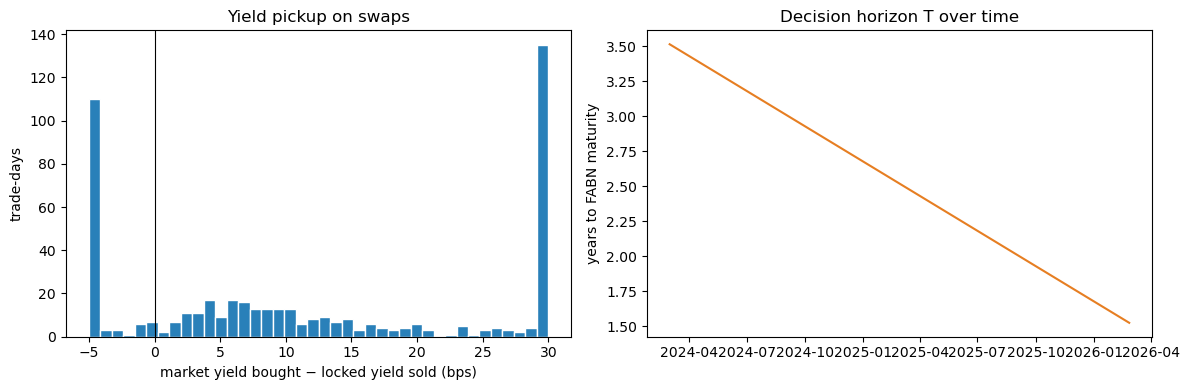

In [15]:
# =============================================================================
# 1A — Diagnose WHY the dynamic strategy trades (run on the base dyn_df)
# =============================================================================
# On every trade-day, compare the notional-weighted MARKET yield bought against
# the locked BOOK yield given up on sells. If pickups cluster near zero while the
# horizon T is large, trades are driven by tiny yield wiggles amplified by T
# beating a one-time bid-ask cost — the case for an LP no-trade band (kappa) or a
# lower rebalance frequency (reopt_every), explored in 1B below.
trd_days = dyn_df[dyn_df["pickup_bps"].notna()].copy()
print(f"Trade-days with both buys & sells : {len(trd_days)}/{nD}")
print("\nYield pickup (market bought − locked sold), bps:")
print(trd_days["pickup_bps"].describe().to_string())
for thr in (1, 2, 5):
    print(f"  share of trade-days with pickup < {thr} bps : "
          f"{(trd_days['pickup_bps'] < thr).mean()*100:.1f}%")
print(f"\nMean horizon T (yrs to maturity)  : {dyn_df['horizon_T'].mean():.2f}")
print(f"Mean daily notional traded        : ${dyn_df['traded_notional'].mean():,.0f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trd_days["pickup_bps"].clip(-5, 30), bins=40, color="#2980b9", edgecolor="white")
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("Yield pickup on swaps")
ax[0].set_xlabel("market yield bought − locked yield sold (bps)")
ax[0].set_ylabel("trade-days")
ax[1].plot(dyn_df["date"], dyn_df["horizon_T"], color="#e67e22")
ax[1].set_title("Decision horizon T over time")
ax[1].set_ylabel("years to FABN maturity")
plt.tight_layout(); plt.show()

Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set paramete

,kappa,reopt_every,dyn_net,adv_vs_static,turnover,notional,trade_days,adv_%
0,10,1,3.200025e+07,4.240280e+06,2.662034e+06,7.038174e+09,498,15.274803
1,10,5,3.189882e+07,4.138854e+06,2.264606e+06,4.490776e+09,100,14.909436
2,5,5,3.167115e+07,3.911186e+06,3.428081e+06,6.216163e+09,100,14.089302
3,1,63,3.166356e+07,3.903597e+06,1.930171e+06,2.296508e+09,8,14.061964
4,2,63,3.148019e+07,3.720225e+06,1.800478e+06,2.114428e+09,8,13.401405
5,5,1,3.127220e+07,3.512231e+06,4.533550e+06,1.023884e+10,498,12.652143
6,2,21,3.125778e+07,3.497811e+06,3.139043e+06,4.641478e+09,24,12.600197
7,1,21,3.120497e+07,3.445001e+06,3.410970e+06,4.970483e+09,24,12.409962
8,5,63,3.118207e+07,3.422102e+06,1.332117e+06,1.745179e+09,8,12.327473
9,5,21,3.116898e+07,3.409014e+06,2.156522e+06,3.545921e+09,24,12.280324


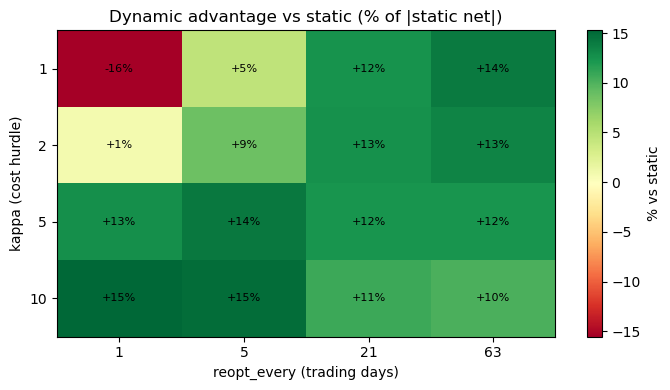

In [16]:
# =============================================================================
# 1B — Turnover levers: kappa (LP cost hurdle) × reopt_every (rebalance frequency)
# =============================================================================
# Static is the same baseline for every cell (solve once on day 0, then hold).
# Each dynamic run is a full daily backtest, so this is ~16 backtests — a few
# minutes at STEP=1. Lower the grid or raise STEP for a quick trial.
import itertools

sta_total = sta_df["Net"].sum()
_den = abs(sta_total) if abs(sta_total) > 1.0 else float("nan")   # guard divide-by-zero
_rows = []
for _kappa, _every in itertools.product([1, 2, 5, 10], [1, 5, 21, 63]):
    _P = dict(PARAMS, kappa=_kappa)
    _df, _ = run_daily(dynamic=True, reopt_every=_every, params=_P)
    _dyn = _df["Net"].sum()
    _rows.append(dict(kappa=_kappa, reopt_every=_every, dyn_net=_dyn,
                      adv_vs_static=_dyn - sta_total,
                      turnover=_df["Turnover"].sum(),
                      notional=_df["traded_notional"].sum(),
                      trade_days=int((_df["n_trades"] > 0).sum())))
    print(f"  kappa={_kappa:<2} reopt_every={_every:<2} -> dyn ${_dyn/1e6:6.2f}M "
          f"(vs static {(_dyn-sta_total)/_den*100:+.1f}%)  turnover ${_df['Turnover'].sum()/1e6:.2f}M")

sweep = pd.DataFrame(_rows)
sweep["adv_%"] = sweep["adv_vs_static"] / _den * 100
print(f"\nSTATIC baseline net = ${sta_total:,.0f}"
      + ("" if abs(sta_total) > 1.0 else "   <-- ~0, so adv_% is n/a; compare dyn_net directly"))
display(sweep.sort_values("dyn_net", ascending=False).reset_index(drop=True))

# Heatmap: dynamic advantage vs static across the lever grid
piv = sweep.pivot(index="kappa", columns="reopt_every", values="adv_%")
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("reopt_every (trading days)"); ax.set_ylabel("kappa (cost hurdle)")
ax.set_title("Dynamic advantage vs static (% of |static net|)")
for (i, j), v in np.ndenumerate(piv.values):
    ax.text(j, i, f"{v:+.0f}%" if np.isfinite(v) else "n/a", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="% vs static"); plt.tight_layout(); plt.show()

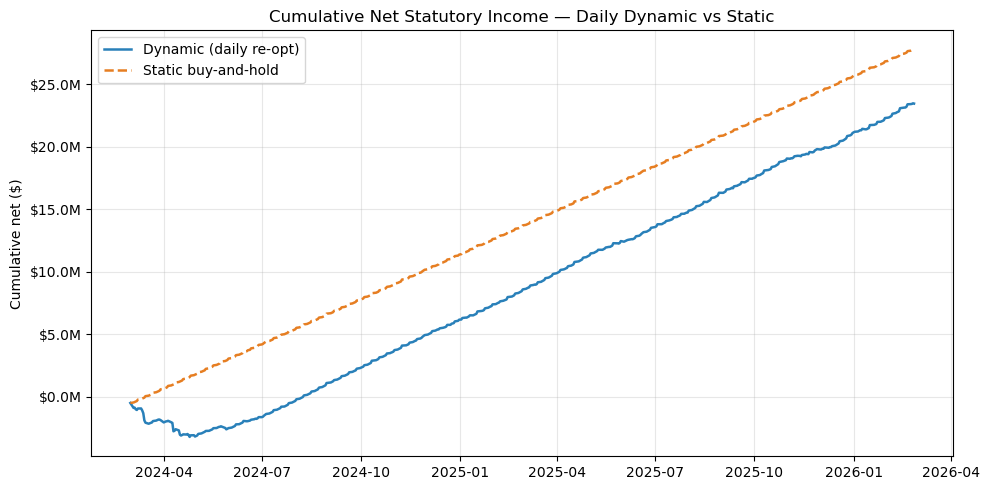

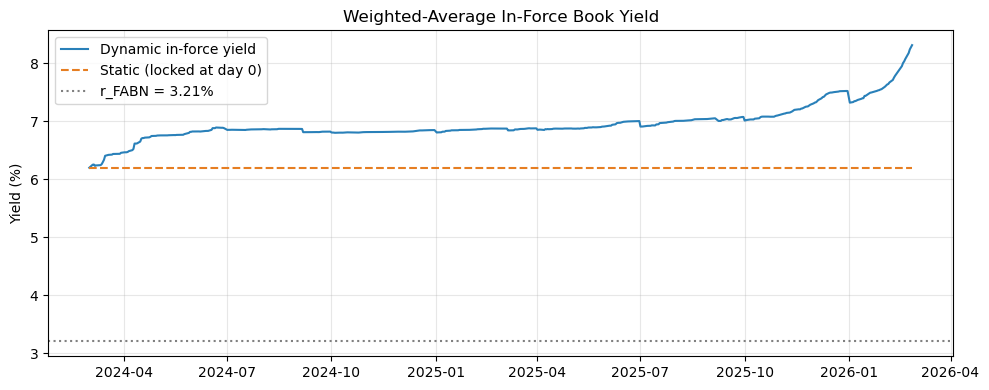

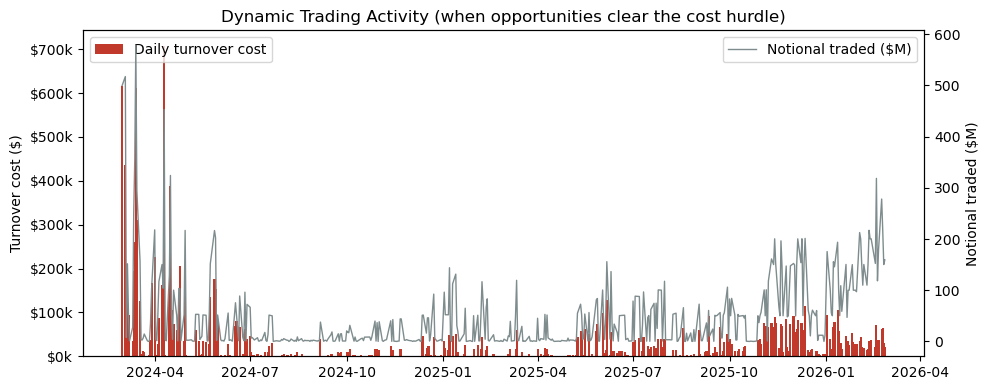

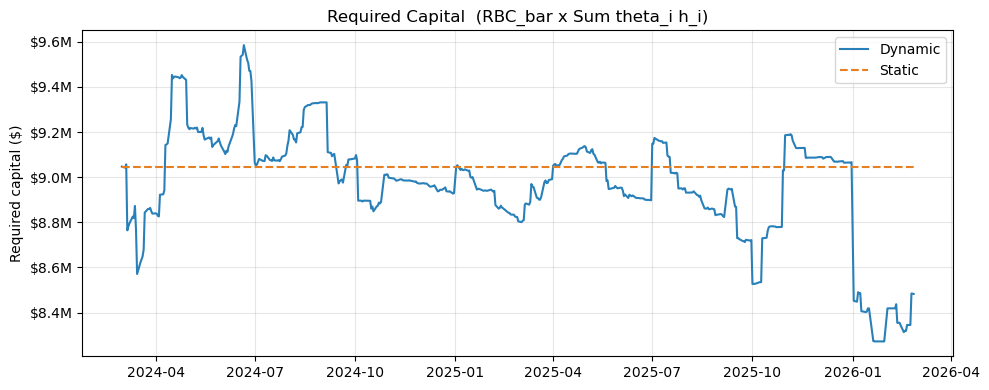

In [17]:
# Fig 1: cumulative net statutory income, dynamic vs static
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dyn_df["date"], dyn_df["CumNet"], color="#2980b9", lw=1.8, label="Dynamic (daily re-opt)")
ax.plot(sta_df["date"], sta_df["CumNet"], color="#e67e22", lw=1.8, ls="--", label="Static buy-and-hold")
ax.set_title("Cumulative Net Statutory Income — Daily Dynamic vs Static")
ax.set_ylabel("Cumulative net ($)"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"${v/1e6:.1f}M"))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Fig 2: in-force weighted book yield over time
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dyn_df["date"], dyn_df["wavg_book_yield"]*100, color="#2980b9", lw=1.5, label="Dynamic in-force yield")
ax.plot(sta_df["date"], sta_df["wavg_book_yield"]*100, color="#e67e22", lw=1.5, ls="--", label="Static (locked at day 0)")
ax.axhline(r_FABN*100, color="grey", ls=":", label=f"r_FABN = {r_FABN*100:.2f}%")
ax.set_title("Weighted-Average In-Force Book Yield"); ax.set_ylabel("Yield (%)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Fig 3: daily turnover paid + trade count (dynamic)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(dyn_df["date"], dyn_df["Turnover"], width=2.0, color="#c0392b", label="Daily turnover cost")
ax.set_ylabel("Turnover cost ($)"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"${v/1e3:.0f}k"))
ax2 = ax.twinx(); ax2.plot(dyn_df["date"], dyn_df["traded_notional"]/1e6, color="#7f8c8d", lw=1, label="Notional traded ($M)")
ax2.set_ylabel("Notional traded ($M)")
ax.set_title("Dynamic Trading Activity (when opportunities clear the cost hurdle)")
ax.legend(loc="upper left"); ax2.legend(loc="upper right"); plt.tight_layout(); plt.show()

# Fig 4: required capital over time
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dyn_df["date"], dyn_df["req_capital"], color="#2980b9", lw=1.5, label="Dynamic")
ax.plot(sta_df["date"], sta_df["req_capital"], color="#e67e22", lw=1.5, ls="--", label="Static")
ax.set_title("Required Capital  (RBC_bar x Sum theta_i h_i)"); ax.set_ylabel("Required capital ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"${v/1e6:.1f}M"))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Section 6 — IMR: completing the picture (sale gains recognized over time)

The earlier sections are **conservative** — they count only coupon-spread income and never credit the
dynamic strategy for *selling appreciated bonds*. **IMR** fixes that the SAP-correct way: a realized,
rate-driven gain/loss on a sale goes into the **Interest Maintenance Reserve** and is **amortized into
income over the sold bond's remaining life — never booked all at once** (that would be the
"liquidation proceeds" anti-pattern). It is an **accounting consequence**: `solve_day` is unchanged;
IMR only re-times recognition in the reported P&L.

To avoid judging dynamic only on its **worst** cell, we plot **two** dynamic scenarios:
- **BASE** = `kappa=1, reopt_every=1` — daily rebalancing at full bid-ask (the strawman).
- **TUNED** = `reopt_every=21, kappa=2` — ~monthly rebalancing with a modest cost hurdle (a realistic
  operating point from the 1B sweep).

For each we show **no-IMR** (coupons only), **IMR released in-window** (gradual, over the 2y test), and
**IMR fully recognized** (adds the IMR balance still amortizing past the backtest end ≈ what you'd
ultimately book). Static never sells, so its line is unchanged — IMR only moves the **dynamic** lines.

In [ ]:
# =============================================================================
# Section 6 — IMR: recognizing realized gains/losses on sales (gradually)
# =============================================================================
# IMR is an accounting CONSEQUENCE; it does not change solve_day's decision. We
# show TWO dynamic scenarios so the picture isn't judged only on the worst cell:
#   * BASE  = PARAMS (kappa=1, reopt_every=1) -> daily, full bid-ask = WORST case.
#   * TUNED = a realistic operating point (monthly rebalance + a modest hurdle).
# For each: no-IMR (coupons only) vs with-IMR (rate-driven sale gains amortized
# over the sold bond's remaining life). Static never sells -> IMR ~ 0, unchanged.
TUNED_REOPT, TUNED_KAPPA = 21, 2
TUNED = dict(PARAMS, kappa=TUNED_KAPPA)

dyn_noimr_df, _       = run_daily(dynamic=True, use_imr=False)                                        # base, no IMR
dyn_tuned_df, _       = run_daily(dynamic=True, reopt_every=TUNED_REOPT, params=TUNED, use_imr=True)  # tuned, IMR
dyn_tuned_noimr_df, _ = run_daily(dynamic=True, reopt_every=TUNED_REOPT, params=TUNED, use_imr=False) # tuned, no IMR

sta_net = sta_df["Net"].sum()
def _summ(df):
    net = df["Net"].sum()
    rem = df["IMR_balance"].iloc[-1] if "IMR_balance" in df else 0.0
    return net, net + rem
_p = lambda x: f"{(x-sta_net)/abs(sta_net)*100:+5.1f}% vs static"

bn, _      = _summ(dyn_noimr_df)            # base, no IMR
b_in, b_fl = _summ(dyn_df)                  # base, IMR (dyn_df runs with use_imr=True)
tn, _      = _summ(dyn_tuned_noimr_df)      # tuned, no IMR
t_in, t_fl = _summ(dyn_tuned_df)            # tuned, IMR

print("="*80)
print(f"  STATIC                                              : ${sta_net:,.0f}")
print(f"  -- BASE  (daily re-opt, kappa=1)  = WORST case ---------------------------------")
print(f"  Dynamic, no IMR                                     : ${bn:,.0f}  ({_p(bn)})")
print(f"  Dynamic, IMR in-window                              : ${b_in:,.0f}  ({_p(b_in)})")
print(f"  Dynamic, IMR fully recognized                       : ${b_fl:,.0f}  ({_p(b_fl)})")
print(f"  -- TUNED (reopt_every={TUNED_REOPT}, kappa={TUNED_KAPPA}) = realistic pacing ---------------------")
print(f"  Dynamic, no IMR                                     : ${tn:,.0f}  ({_p(tn)})")
print(f"  Dynamic, IMR in-window                              : ${t_in:,.0f}  ({_p(t_in)})")
print(f"  Dynamic, IMR fully recognized                       : ${t_fl:,.0f}  ({_p(t_fl)})")
print("-"*80)
print(f"  Gains harvested   base ${dyn_df['realized_gain'].sum():,.0f} | tuned ${dyn_tuned_df['realized_gain'].sum():,.0f}")
print(f"  Turnover paid     base ${dyn_df['Turnover'].sum():,.0f} | tuned ${dyn_tuned_df['Turnover'].sum():,.0f}")
print("="*80)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
# (1) cumulative net — static vs base(no-IMR, worst) vs base(IMR) vs TUNED(IMR)
ax[0].plot(sta_df["date"], sta_df["CumNet"], color="#e67e22", ls="--", lw=1.6, label="Static")
ax[0].plot(dyn_noimr_df["date"], dyn_noimr_df["CumNet"], color="#bdc3c7", lw=1.3, label="Dyn base, no IMR (worst)")
ax[0].plot(dyn_df["date"], dyn_df["CumNet"], color="#7f8c8d", lw=1.5, label="Dyn base, IMR")
ax[0].plot(dyn_tuned_df["date"], dyn_tuned_df["CumNet"], color="#2980b9", lw=2.2,
           label=f"Dyn TUNED (reopt {TUNED_REOPT}, k={TUNED_KAPPA}), IMR")
ax[0].set_title("Cumulative net statutory income"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
# (2) IMR balance over time — base vs tuned
ax[1].plot(dyn_df["date"], dyn_df["IMR_balance"], color="#7f8c8d", lw=1.5, label="Base")
ax[1].plot(dyn_tuned_df["date"], dyn_tuned_df["IMR_balance"], color="#2980b9", lw=1.7, label="Tuned")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_title("IMR balance (unamortized realized gains)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
# (3) realized vs recognized (tuned) — IMR re-times the gain into income
ax[2].plot(dyn_tuned_df["date"], dyn_tuned_df["realized_gain"].cumsum(), color="#c0392b", lw=1.6, label="Realized gains (cum)")
ax[2].plot(dyn_tuned_df["date"], dyn_tuned_df["IMR_release"].cumsum(), color="#27ae60", lw=1.6, label="IMR released to income (cum)")
ax[2].set_title("Realized vs recognized — tuned (IMR re-times the gain)"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
ax[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
plt.tight_layout(); plt.show()

---
## Notes

- **Daily decision, horizon-valued:** each day weighs a holding over its remaining life to FABN
  maturity, so a one-time bid-ask cost is judged against the income it earns over the horizon — that
  is why worthwhile opportunities are taken instead of churning or freezing.
- **All four economics in the swap:** trading cost (real bid-ask, both buys and sells), capital-cost
  change ($T\lambda\theta h$), lending revenue ($r_{save}$ on facility surplus), borrowing cost
  ($r_{borrow}$ on shortfall).
- **Amortized cost:** retained lots keep their locked yield; only new buys re-strike at market — the
  true "pickup minus what you give up."
- **Turnover control (Section 5):** `kappa` (cost hurdle) and `reopt_every` (rebalance frequency)
  temper over-trading; the base daily-full-cost run is the worst case.
- **IMR (Section 6):** realized **rate-driven** sale gains/losses are now recognized via an Interest
  Maintenance Reserve — amortized into income over each sold bond's remaining life, **never booked at
  the sale date** (no "liquidation proceeds" inflation). IMR is an *accounting consequence*: it does
  **not** change `solve_day`'s trade. **AVR** (the credit-default reserve) remains out of scope.
- **Runtime:** the IRR precompute (Section 1) is the slow step; set `STEP>1` for a quick trial.